      Age  Income Student Buy Laptop
0  Senior  Medium     Yes        Yes
1  Senior    High      No         No
2  Middle  Medium      No        Yes
3  Senior  Medium     Yes        Yes
4   Youth    High     Yes        Yes
Total records: 100


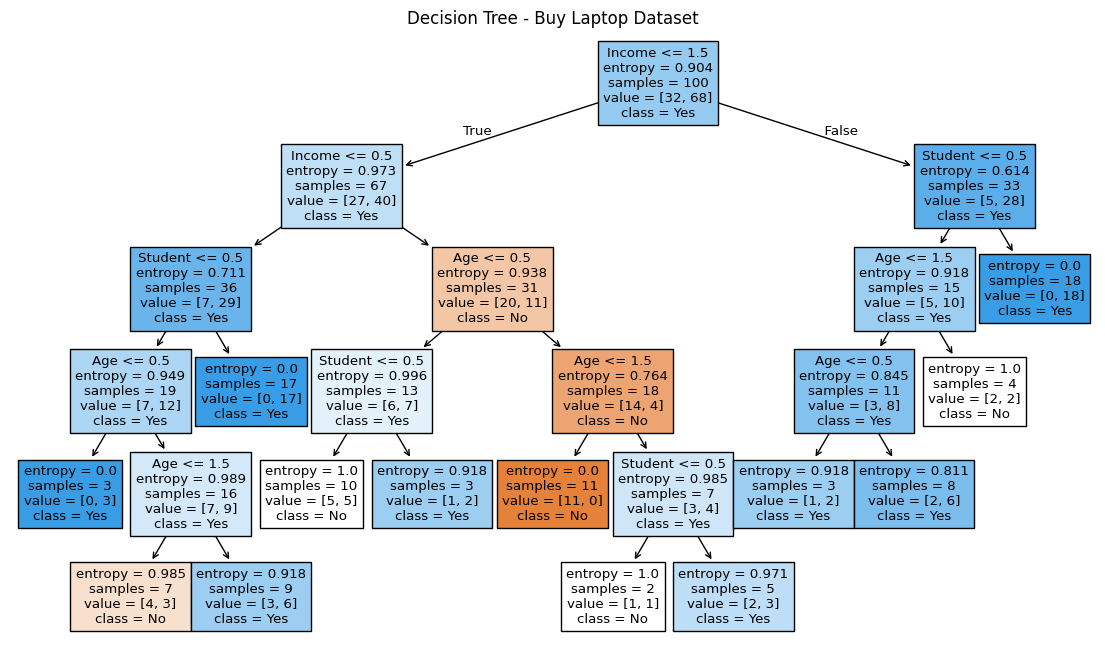

In [1]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

import pandas as pd
import random

# Possible values
age = ['Youth', 'Middle', 'Senior']
income = ['Low', 'Medium', 'High']
student = ['Yes', 'No']

data = []

# Generate 100 records using a simple decision logic
for i in range(100):
    a = random.choice(age)
    inc = random.choice(income)
    stu = random.choice(student)

    # Simple rule to generate realistic target
    if (stu == 'Yes' and inc != 'Low') or (a == 'Middle' and inc == 'High'):
        buy = 'Yes'
    elif a == 'Senior' and inc == 'Low':
        buy = 'No'
    else:
        buy = random.choice(['Yes', 'No'])

    data.append([a, inc, stu, buy])

df = pd.DataFrame(data, columns=['Age','Income','Student','Buy Laptop'])

print(df.head())
print("Total records:", len(df))


# Encode categorical data
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df[['Age','Income','Student']]
y = df['Buy Laptop']

# Train Decision Tree
dt = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt.fit(X, y)

# Visualize the tree
plt.figure(figsize=(14,8))
plot_tree(dt,
          feature_names=['Age','Income','Student'],
          class_names=['No','Yes'],
          filled=True)
plt.title("Decision Tree - Buy Laptop Dataset")
plt.show()